# Diseño de filtros digitales IIR
**Análisis y procesamiento de Señales** - Bioingeniería - Fac. de Ingeniería - UNSTA - 2026

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

## Carga de la señal de ECG

Vamos a trabajar con la misma señal de ECG que usamos en la clase anterior.

In [2]:
ecg = np.loadtxt("./ECG.txt")

fs = 200
N = len(ecg)
n = np.arange(N)
t = n / fs

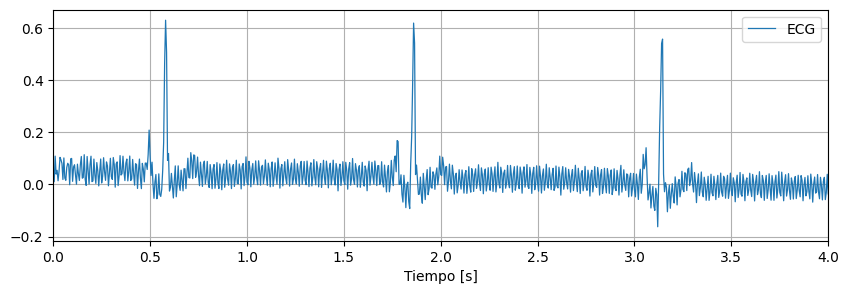

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3))

ax.plot(t, ecg, linewidth=0.9, label="ECG")
ax.set_xlim([0, 4])
ax.set_xlabel("Tiempo [s]")
ax.legend()
ax.grid(True)

## Funciones auxiliares

Definimos funciones para visualizar la respuesta en frecuencia, el diagrama de polos y ceros, y la respuesta al impulso.

In [4]:
from zplane_graph import zplane

In [5]:
def obtain_response(b, a, fs, N):
    w, H = sp.signal.freqz(b, a, fs=fs, worN=N)
    return w, H

def plot_response(w, H, fs, ylim_limits=(-60, 10)):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].plot(w, 20*np.log10(np.abs(H) + 1e-12))
    ax[1].plot(w, np.angle(H, deg=True))
    ax[0].grid(True)
    ax[1].grid(True)

    ax[0].set_ylabel("|H( $\\omega$ )| dB")
    ax[1].set_ylabel("Fase (deg)")
    ax[0].set_xlabel("f [Hz]")
    ax[1].set_xlabel("f [Hz]")

    ax[0].set_ylim(ylim_limits)
    ax[0].set_xlim([0, fs/2])
    ax[1].set_xlim([0, fs/2])

    plt.tight_layout()

In [6]:
def plot_impulse_response(b, a, M=50):
    """Calcula y grafica la respuesta al impulso del filtro."""
    impulse = np.zeros(M)
    impulse[0] = 1.0
    h = sp.signal.lfilter(b, a, impulse)

    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    ax.stem(np.arange(M), h)
    ax.set_xlabel("n (muestras)")
    ax.set_ylabel("h[n]")
    ax.set_title("Respuesta al impulso")
    ax.grid(True)
    plt.tight_layout()
    return h

## Espectro de la señal

Veamos la FFT de la señal para identificar las componentes frecuenciales.

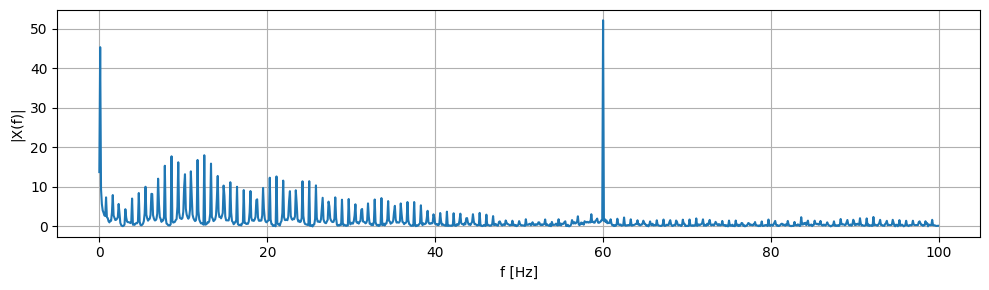

In [7]:
def plot_spectrum(signal, fs, N):
    """Grafica el espectro (módulo de la FFT) de la señal."""
    signal_fft = np.fft.fft(signal)
    f = (fs / N) * np.arange(N)

    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    ax.plot(f[:int(N/2)], np.abs(signal_fft)[:int(N/2)])
    ax.set_xlabel("f [Hz]")
    ax.set_ylabel("|X(f)|")
    ax.grid(True)
    plt.tight_layout()

plot_spectrum(ecg, fs, N)

---
# Parte 1: Filtro pasa-bajo Butterworth (paso a paso)

Vamos a diseñar un filtro pasa-bajo IIR de tipo **Butterworth** con frecuencia de corte $f_c = 50$ Hz.

El proceso de diseño sigue estos pasos:
1. Definir la frecuencia de corte y el orden del filtro.
2. Aplicar el **pre-warping** para compensar la distorsión de la transformada bilineal.
3. Encontrar el filtro **normalizado** de Butterworth pasa-bajo.
4. Transformar (desnormalizar) el filtro a la frecuencia deseada.
5. Aplicar la **transformada bilineal** para pasar del plano $s$ al plano $z$.
6. Obtener los coeficientes $b$ y $a$ del filtro digital.
7. Aplicar el filtro a la señal.

### Paso 1: Definir frecuencia de corte y orden del filtro

In [8]:
fc = 50           # Frecuencia de corte en Hz
wc = 2 * np.pi * fc   # Frecuencia angular de corte
N_filt = 4        # Orden del filtro

print(f"Frecuencia de corte: fc = {fc} Hz")
print(f"Frecuencia angular: wc = {wc:.2f} rad/s")
print(f"Orden del filtro: N = {N_filt}")

Frecuencia de corte: fc = 50 Hz
Frecuencia angular: wc = 314.16 rad/s
Orden del filtro: N = 4


### Paso 2: Pre-warping

La transformada bilineal genera una distorsión en frecuencia. Para compensarla, aplicamos pre-warping a la frecuencia de corte:

$$\Omega = 2 f_s \cdot \tan\left(\frac{\omega_c}{2 f_s}\right)$$

In [9]:
warped = 2 * fs * np.tan(wc / (2 * fs))

print(f"Frecuencia pre-warped: {warped:.2f} rad/s")
print(f"Frecuencia original:   {wc:.2f} rad/s")
print(f"Diferencia:            {warped - wc:.2f} rad/s")

Frecuencia pre-warped: 400.00 rad/s
Frecuencia original:   314.16 rad/s
Diferencia:            85.84 rad/s


### Paso 3: Filtro normalizado de Butterworth

Obtenemos el prototipo de filtro pasa-bajo normalizado ($\nu_c = 1$) en formato ZPK (zeros, poles, gain).

In [10]:
z, p, k = sp.signal.buttap(N_filt)

print(f"Ceros: {z}")
print(f"Polos: {p}")
print(f"Ganancia: {k}")

Ceros: []
Polos: [-0.38268343+0.92387953j -0.92387953+0.38268343j -0.92387953-0.38268343j
 -0.38268343-0.92387953j]
Ganancia: 1.0


### Paso 4: Desnormalización

Transformamos el filtro normalizado a la frecuencia de corte deseada (utilizando la frecuencia pre-warped).

In [11]:
z, p, k = sp.signal.lp2lp_zpk(z, p, k, wo=warped)

print(f"Ceros desnormalizados: {z}")
print(f"Polos desnormalizados: {p}")
print(f"Ganancia: {k}")

Ceros desnormalizados: []
Polos desnormalizados: [-153.07337295+369.551813j   -369.551813  +153.07337295j
 -369.551813  -153.07337295j -153.07337295-369.551813j  ]
Ganancia: 25599999999.999985


> **Nota:** Los pasos 3 y 4 se pueden resumir con una sola función:
> ```python
> z, p, k = sp.signal.butter(N_filt, warped, btype='low', analog=True, output='zpk')
> ```

### Paso 5: Transformada bilineal

Convertimos el filtro analógico al dominio digital mediante la transformada bilineal.

In [12]:
z_d, p_d, k_d = sp.signal.bilinear_zpk(z, p, k, fs)

print(f"Ceros digitales: {z_d}")
print(f"Polos digitales: {p_d}")
print(f"Ganancia digital: {k_d}")

Ceros digitales: [-1. -1. -1. -1.]
Polos digitales: [6.46815470e-17+0.66817864j 5.92625032e-17+0.19891237j
 5.92625032e-17-0.19891237j 6.46815470e-17-0.66817864j]
Ganancia digital: 0.09398085143379444


### Paso 6: Obtener coeficientes b y a

In [13]:
b_lp, a_lp = sp.signal.zpk2tf(z_d, p_d, k_d)

print(f"Coeficientes b (numerador):   {b_lp}")
print(f"Coeficientes a (denominador): {a_lp}")

Coeficientes b (numerador):   [0.09398085 0.37592341 0.56388511 0.37592341 0.09398085]
Coeficientes a (denominador): [ 1.00000000e+00 -2.47888100e-16  4.86028822e-01 -5.80353904e-17
  1.76648009e-02]


### Análisis del filtro diseñado

Veamos el diagrama de polos y ceros, la respuesta en frecuencia y la respuesta al impulso:

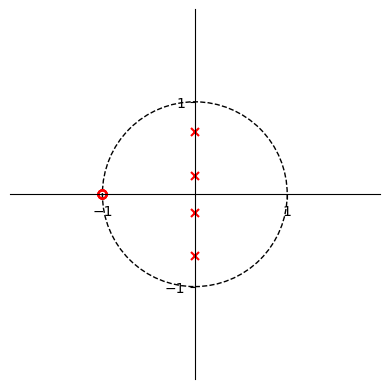

In [14]:
zplane(b_lp, a_lp);

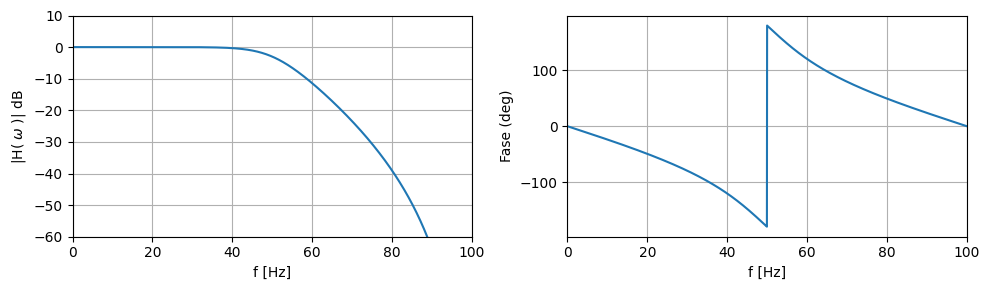

In [15]:
w_resp, H_resp = obtain_response(b_lp, a_lp, fs, N)
plot_response(w_resp, H_resp, fs)

Veamos la respuesta al impulso. Notemos que es **infinita** (pero decae):

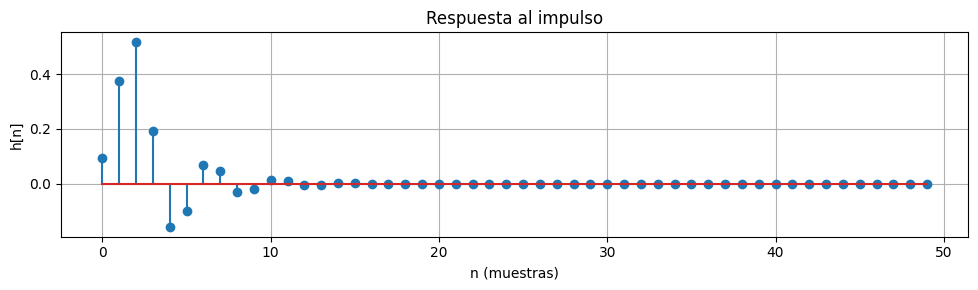

In [16]:
h_resp = plot_impulse_response(b_lp, a_lp, M=50)

### Paso 7: Aplicar el filtro a la señal de ECG

In [17]:
ecg_filt_lp = sp.signal.lfilter(b_lp, a_lp, ecg)

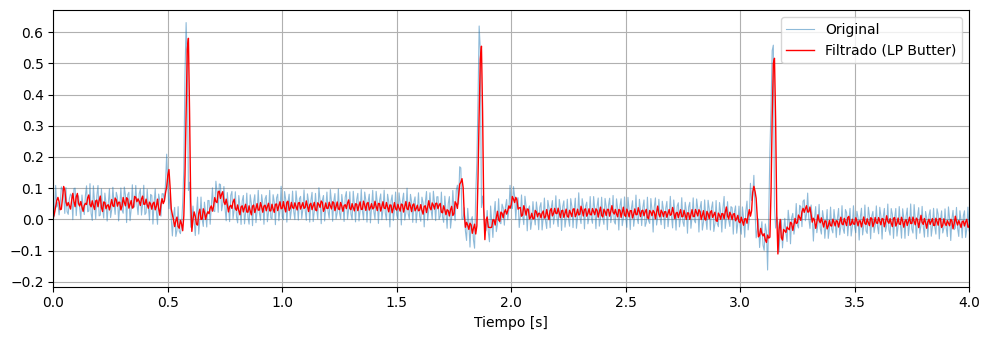

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.plot(t, ecg, linewidth=0.8, label="Original", alpha=0.5)
ax.plot(t, ecg_filt_lp, linewidth=1, color="red", label="Filtrado (LP Butter)")
ax.set_xlim([0, 4])
ax.set_xlabel("Tiempo [s]")
ax.legend()
ax.grid(True)
plt.tight_layout()

### Verificación: comparación de espectros

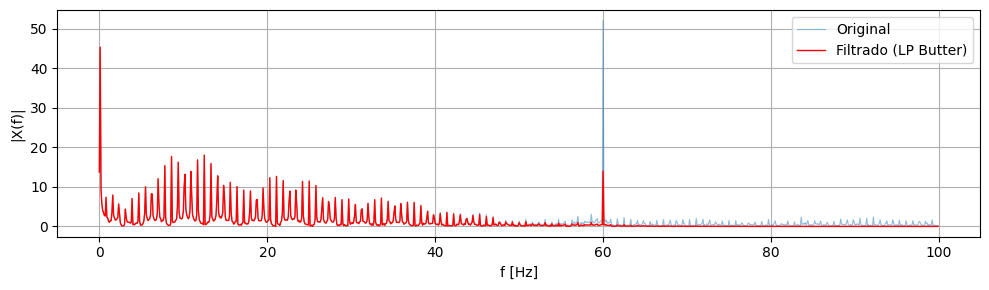

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3))

ecg_fft = np.fft.fft(ecg)
ecg_filt_fft = np.fft.fft(ecg_filt_lp)
f = (fs / N) * np.arange(N)

ax.plot(f[:int(N/2)], np.abs(ecg_fft)[:int(N/2)], linewidth=0.8, alpha=0.5, label="Original")
ax.plot(f[:int(N/2)], np.abs(ecg_filt_fft)[:int(N/2)], linewidth=1, color="red", label="Filtrado (LP Butter)")
ax.set_xlabel("f [Hz]")
ax.set_ylabel("|X(f)|")
ax.legend()
ax.grid(True)
plt.tight_layout()

### Versión simplificada (todo en una función)

Todo el proceso anterior se puede resumir en **una sola función** de scipy. Esta función hace internamente el pre-warping, el diseño del filtro analógico y la transformada bilineal:

In [20]:
b_lp_simple, a_lp_simple = sp.signal.butter(N_filt, fc, fs=fs, btype='low', analog=False)

print(f"Coeficientes b: {b_lp_simple}")
print(f"Coeficientes a: {a_lp_simple}")
print()
print(f"¿Son iguales a los obtenidos paso a paso?")
print(f"  b: {np.allclose(b_lp, b_lp_simple)}")
print(f"  a: {np.allclose(a_lp, a_lp_simple)}")

Coeficientes b: [0.09398085 0.37592341 0.56388511 0.37592341 0.09398085]
Coeficientes a: [ 1.00000000e+00 -2.98931318e-16  4.86028822e-01 -6.79919440e-17
  1.76648009e-02]

¿Son iguales a los obtenidos paso a paso?
  b: True
  a: True


---
# Parte 2: Filtro bloquea-banda Chebyshev Tipo 1 (usando una sola función)

Ahora diseñamos un filtro **bloquea-banda** (bandstop) basado en **Chebyshev Tipo 1** para eliminar la interferencia de línea de 60 Hz de la señal de ECG.

Usamos frecuencias de corte $f_{c1} = 55$ Hz y $f_{c2} = 65$ Hz, un orden de filtro $N = 6$ y un ripple en banda de paso $r_p = 0.1$ dB.

En esta parte usaremos directamente la función de scipy `sp.signal.cheby1` que hace todo el proceso internamente.

In [21]:
# Parámetros del filtro bloquea-banda Chebyshev Tipo 1
fc1_bs = 55       # Frecuencia de corte inferior [Hz]
fc2_bs = 65       # Frecuencia de corte superior [Hz]
N_filt_bs = 6     # Orden del filtro
rp = 0.1          # Ripple en banda de paso [dB]

print(f"Filtro bloquea-banda Chebyshev Tipo 1")
print(f"  Frecuencias de corte: {fc1_bs} - {fc2_bs} Hz")
print(f"  Orden: {N_filt_bs}")
print(f"  Ripple en banda de paso: {rp} dB")

Filtro bloquea-banda Chebyshev Tipo 1
  Frecuencias de corte: 55 - 65 Hz
  Orden: 6
  Ripple en banda de paso: 0.1 dB


### Diseño del filtro (una sola función)

In [22]:
b_bs, a_bs = sp.signal.cheby1(N_filt_bs, rp, [fc1_bs, fc2_bs],
                              btype='bandstop', analog=False,
                              output='ba', fs=fs)

print(f"Coeficientes b (numerador):   {b_bs}")
print(f"Coeficientes a (denominador): {a_bs}")

Coeficientes b (numerador):   [ 0.49408187  1.8549944   5.8663418  11.69603569 20.15484376 26.09752377
 29.59482646 26.09752377 20.15484376 11.69603569  5.8663418   1.8549944
  0.49408187]
Coeficientes a (denominador): [ 1.          3.32092049  9.22357414 16.28073423 24.81805596 28.58592442
 28.84906358 22.75202196 15.72651299  8.21189056  3.70830135  1.06383328
  0.25660992]


### Análisis del filtro

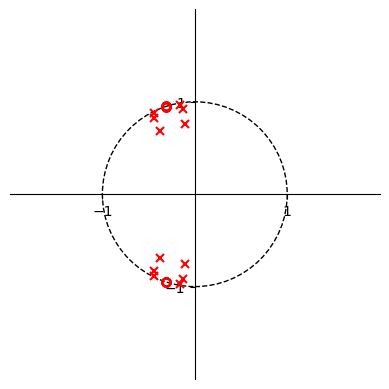

In [23]:
zplane(b_bs, a_bs);

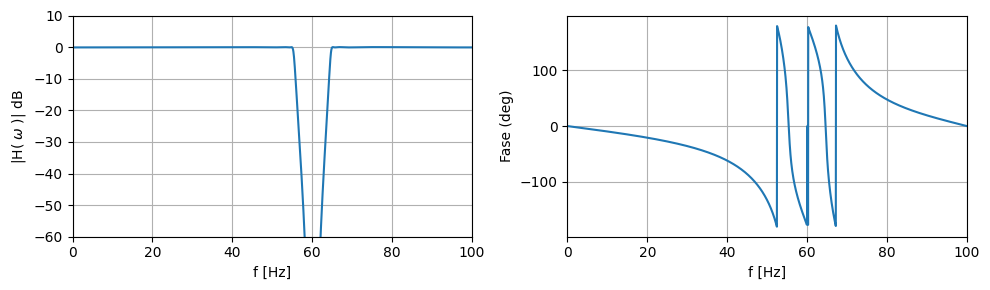

In [24]:
w_bs, H_bs = obtain_response(b_bs, a_bs, fs, N)
plot_response(w_bs, H_bs, fs)

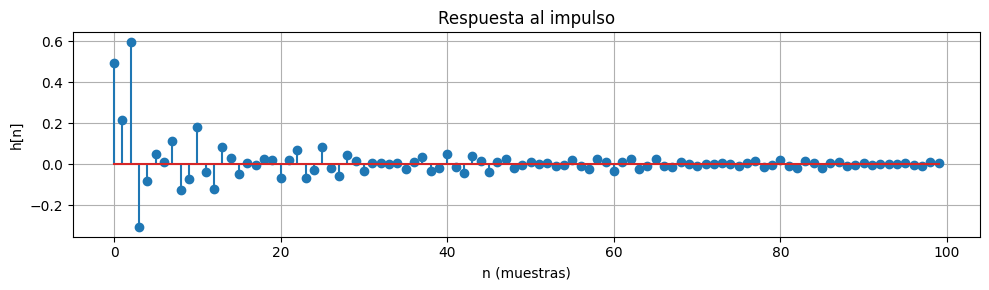

In [25]:
h_bs = plot_impulse_response(b_bs, a_bs, M=100)

### Aplicar el filtro a la señal de ECG

In [26]:
ecg_filt_bs = sp.signal.lfilter(b_bs, a_bs, ecg)

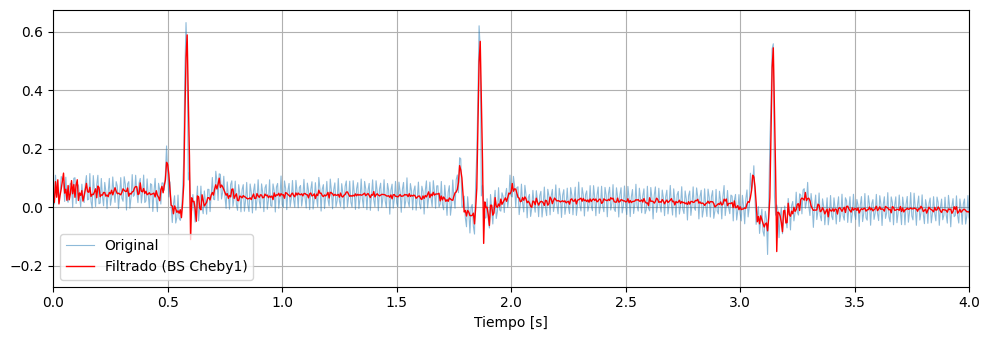

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.plot(t, ecg, linewidth=0.8, label="Original", alpha=0.5)
ax.plot(t, ecg_filt_bs, linewidth=1, color="red", label="Filtrado (BS Cheby1)")
ax.set_xlim([0, 4])
ax.set_xlabel("Tiempo [s]")
ax.legend()
ax.grid(True)
plt.tight_layout()

### Verificación: comparación de espectros

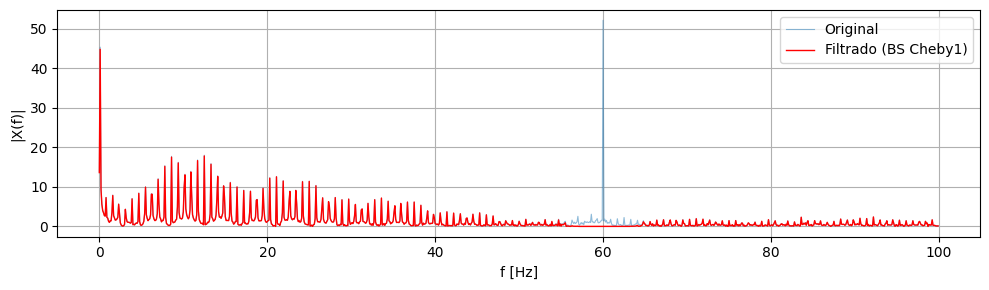

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3))

ecg_fft = np.fft.fft(ecg)
ecg_filt_bs_fft = np.fft.fft(ecg_filt_bs)
f = (fs / N) * np.arange(N)

ax.plot(f[:int(N/2)], np.abs(ecg_fft)[:int(N/2)], linewidth=0.8, alpha=0.5, label="Original")
ax.plot(f[:int(N/2)], np.abs(ecg_filt_bs_fft)[:int(N/2)], linewidth=1, color="red", label="Filtrado (BS Cheby1)")
ax.set_xlabel("f [Hz]")
ax.set_ylabel("|X(f)|")
ax.legend()
ax.grid(True)
plt.tight_layout()

---
# Parte 3: Aplicación en cadena

Podemos aplicar los dos filtros en **cascada**: primero el pasa-bajo Butterworth (elimina ruido de alta frecuencia) y luego el bloquea-banda Chebyshev (elimina la interferencia de 60 Hz).

In [29]:
# Cascada: pasa-bajos → bloquea-banda
ecg_cascade = sp.signal.lfilter(b_bs, a_bs,
                 sp.signal.lfilter(b_lp, a_lp, ecg))

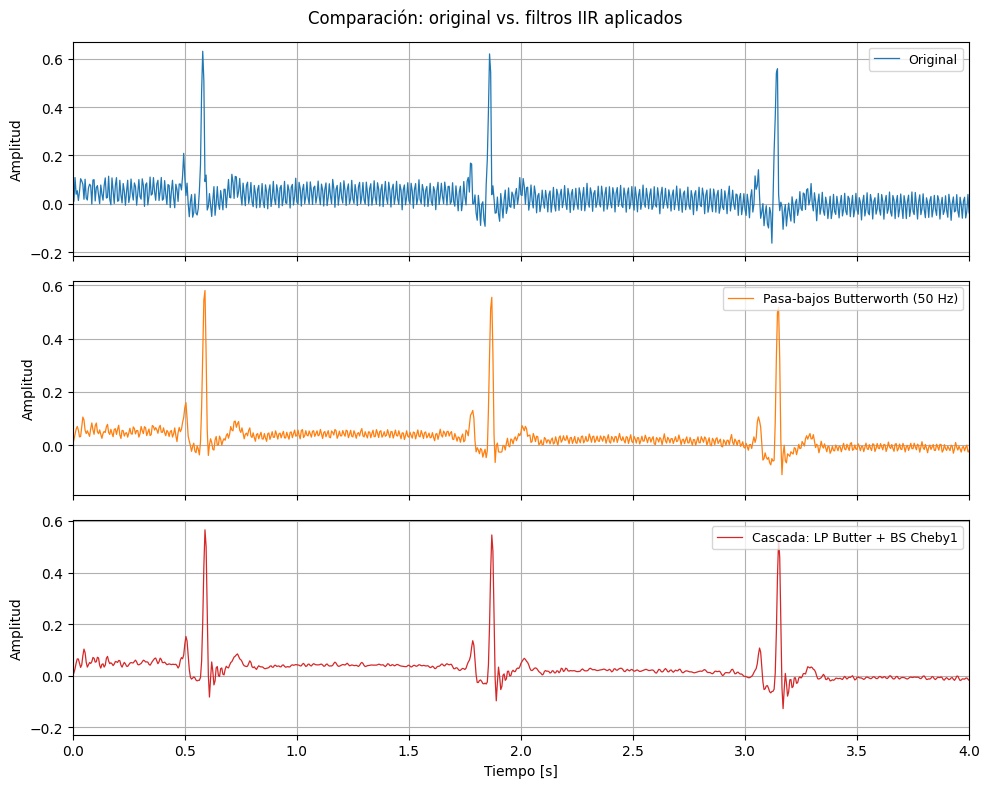

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

for ax, sig, label, color in zip(
    axes,
    [ecg, ecg_filt_lp, ecg_cascade],
    ["Original", "Pasa-bajos Butterworth (50 Hz)", "Cascada: LP Butter + BS Cheby1"],
    ["tab:blue", "tab:orange", "tab:red"]
):
    ax.plot(t, sig, linewidth=0.9, color=color, label=label)
    ax.set_xlim([0, 4])
    ax.set_ylabel("Amplitud")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True)

axes[-1].set_xlabel("Tiempo [s]")
fig.suptitle("Comparación: original vs. filtros IIR aplicados")
plt.tight_layout()

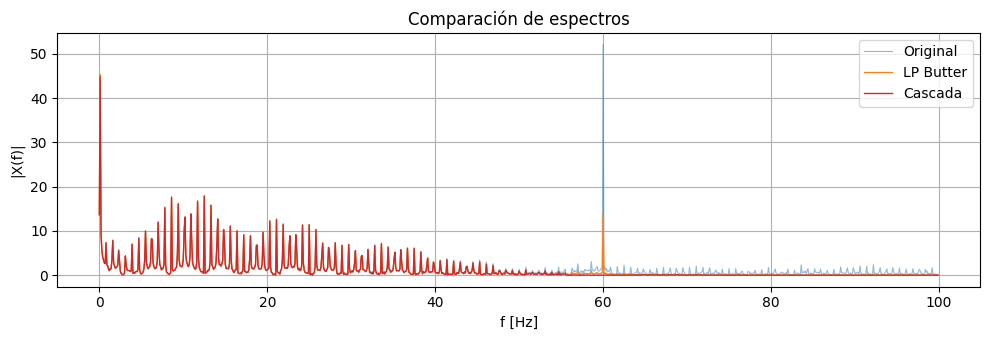

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))

ecg_fft = np.fft.fft(ecg)
ecg_lp_fft = np.fft.fft(ecg_filt_lp)
ecg_cas_fft = np.fft.fft(ecg_cascade)
f = (fs / N) * np.arange(N)

ax.plot(f[:int(N/2)], np.abs(ecg_fft)[:int(N/2)], linewidth=0.8, alpha=0.5, label="Original")
ax.plot(f[:int(N/2)], np.abs(ecg_lp_fft)[:int(N/2)], linewidth=0.9, color="tab:orange", label="LP Butter")
ax.plot(f[:int(N/2)], np.abs(ecg_cas_fft)[:int(N/2)], linewidth=1, color="tab:red", label="Cascada")
ax.set_xlabel("f [Hz]")
ax.set_ylabel("|X(f)|")
ax.set_title("Comparación de espectros")
ax.legend()
ax.grid(True)
plt.tight_layout()

---
# Extra: Convertir el filtro IIR en cascada a un filtro FIR equivalente

Un filtro IIR tiene *respuesta al impulso infinita*. Sin embargo, en la práctica la respuesta al impulso **decae** y eventualmente se vuelve despreciable. Podemos entonces **truncarla** a $M$ muestras para obtener un filtro FIR aproximado.

El procedimiento es:
1. Generar un impulso $\delta[n]$ de largo $M$.
2. Pasarlo por el filtro IIR en cascada para obtener la respuesta al impulso $h[n]$.
3. Usar esas $M$ muestras de $h[n]$ como coeficientes del filtro FIR equivalente.

### Paso 1: Obtener la respuesta al impulso truncada

In [32]:
M_fir = 256  # Largo del filtro FIR

# Crear impulso unitario
impulse = np.zeros(M_fir)
impulse[0] = 1.0

# Pasar el impulso por los dos filtros IIR en cascada
h_fir = sp.signal.lfilter(b_bs, a_bs,
            sp.signal.lfilter(b_lp, a_lp, impulse))

print(f"Coeficientes del filtro FIR: {len(h_fir)} muestras")

Coeficientes del filtro FIR: 256 muestras


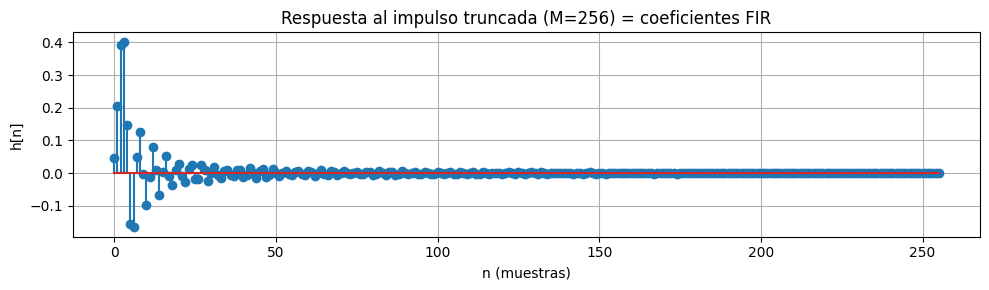

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.stem(h_fir)
ax.set_title(f"Respuesta al impulso truncada (M={M_fir}) = coeficientes FIR")
ax.set_xlabel("n (muestras)")
ax.set_ylabel("h[n]")
ax.grid(True)
plt.tight_layout()

### Paso 2: Comparar respuestas en frecuencia

Veamos qué tan bien el filtro FIR aproxima al IIR original:

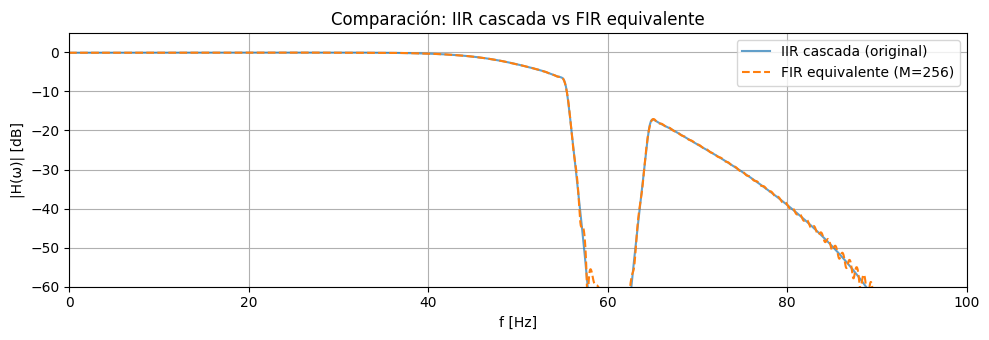

In [34]:
# Respuesta en frecuencia del filtro FIR equivalente
w_fir_eq, H_fir_eq = sp.signal.freqz(h_fir, [1], fs=fs, worN=N)

# Respuesta combinada del IIR original
w_iir_comb, H_lp_comb = sp.signal.freqz(b_lp, a_lp, fs=fs, worN=N)
_, H_bs_comb = sp.signal.freqz(b_bs, a_bs, fs=fs, worN=N)
H_iir_total = H_lp_comb * H_bs_comb

fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.plot(w_iir_comb, 20*np.log10(np.abs(H_iir_total) + 1e-12),
        label="IIR cascada (original)", linewidth=1.5, alpha=0.7)
ax.plot(w_fir_eq, 20*np.log10(np.abs(H_fir_eq) + 1e-12),
        label=f"FIR equivalente (M={M_fir})", linewidth=1.5, linestyle="--")
ax.set_xlabel("f [Hz]")
ax.set_ylabel("|H(ω)| [dB]")
ax.set_xlim([0, fs/2])
ax.set_ylim([-60, 5])
ax.set_title("Comparación: IIR cascada vs FIR equivalente")
ax.legend()
ax.grid(True)
plt.tight_layout()

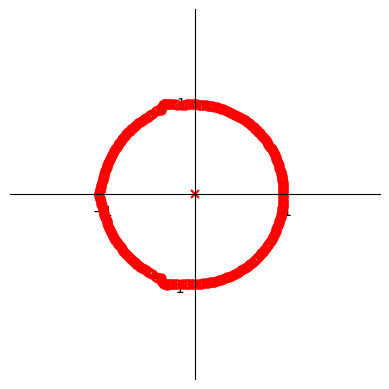

In [38]:
zplane(h_fir, [1]);

### Paso 3: Aplicar el filtro FIR equivalente a la señal

In [35]:
ecg_fir_eq = sp.signal.lfilter(h_fir, [1], ecg)

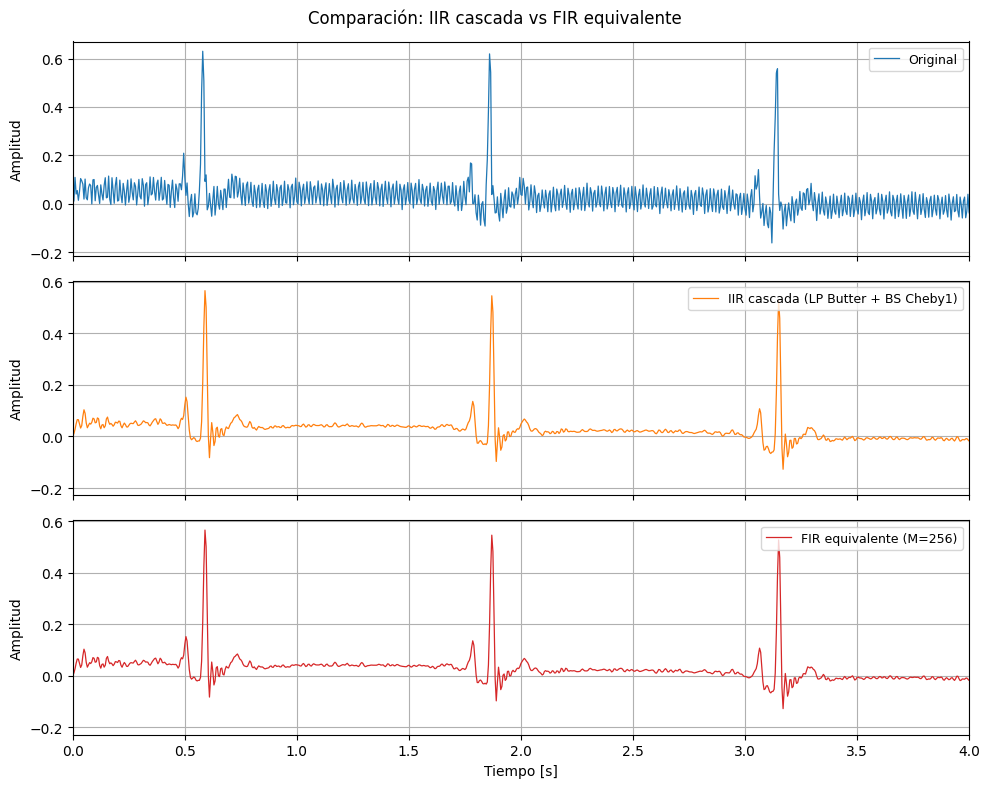

In [36]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

for ax, sig, label, color in zip(
    axes,
    [ecg, ecg_cascade, ecg_fir_eq],
    ["Original",
     "IIR cascada (LP Butter + BS Cheby1)",
     f"FIR equivalente (M={M_fir})"],
    ["tab:blue", "tab:orange", "tab:red"]
):
    ax.plot(t, sig, linewidth=0.9, color=color, label=label)
    ax.set_xlim([0, 4])
    ax.set_ylabel("Amplitud")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True)

axes[-1].set_xlabel("Tiempo [s]")
fig.suptitle("Comparación: IIR cascada vs FIR equivalente")
plt.tight_layout()

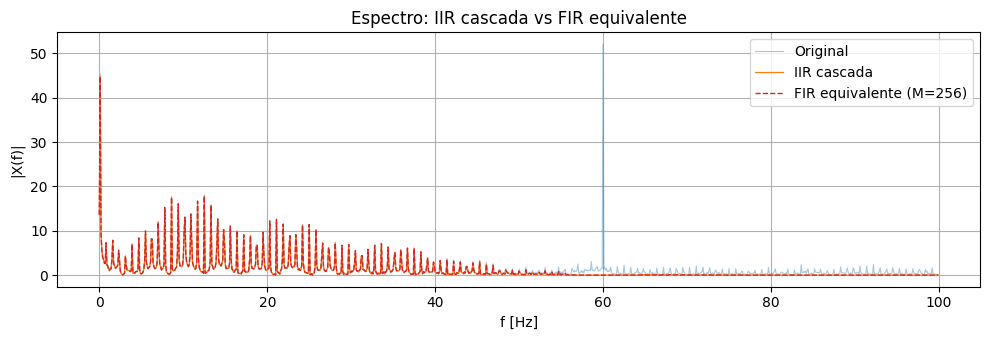

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))

ecg_cas_fft = np.fft.fft(ecg_cascade)
ecg_fir_fft = np.fft.fft(ecg_fir_eq)
f = (fs / N) * np.arange(N)

ax.plot(f[:int(N/2)], np.abs(ecg_fft)[:int(N/2)], linewidth=0.8, alpha=0.4, label="Original")
ax.plot(f[:int(N/2)], np.abs(ecg_cas_fft)[:int(N/2)], linewidth=0.9, color="tab:orange", label="IIR cascada")
ax.plot(f[:int(N/2)], np.abs(ecg_fir_fft)[:int(N/2)], linewidth=1, color="tab:red", linestyle="--", label=f"FIR equivalente (M={M_fir})")
ax.set_xlabel("f [Hz]")
ax.set_ylabel("|X(f)|")
ax.set_title("Espectro: IIR cascada vs FIR equivalente")
ax.legend()
ax.grid(True)
plt.tight_layout()

## Resumen

| Filtro | Tipo | Método | Orden | Objetivo |
|--------|------|--------|-------|----------|
| Pasa-bajos | Butterworth | Paso a paso | 4 | Eliminar ruido > 50 Hz |
| Bloquea-banda | Chebyshev Tipo 1 | Una función (`cheby1`) | 6 | Eliminar interferencia 55–65 Hz |
| FIR equivalente | Truncamiento de h[n] | `lfilter` con impulso | 256 | Aproximar la cascada IIR |

**Observaciones:**
- Los filtros IIR tienen **polos y ceros**, lo que les permite lograr transiciones más abruptas con menor orden que los FIR.
- La respuesta al impulso IIR es **infinita** (pero decae), a diferencia de los FIR que tienen respuesta finita.
- Los filtros IIR **no tienen fase lineal** en general (a diferencia de los FIR), lo cual puede distorsionar la forma de onda.
- Para convertir un IIR en FIR basta con **truncar su respuesta al impulso**: pasar un impulso por el filtro y tomar las primeras $M$ muestras como coeficientes.
- Aplicando los filtros en cascada se elimina tanto el ruido de alta frecuencia como la interferencia de red eléctrica.